# XGBoost Model Training for Crypto Price Direction Prediction

This notebook trains an XGBoost classifier to predict crypto price direction (UP/DOWN/NEUTRAL) using technical indicators and features.

## Overview
- **Task**: Multi-class classification (3 classes: DOWN, NEUTRAL, UP)
- **Model**: XGBoost with hyperparameter tuning via Optuna
- **Data Split**: Time-series split (no shuffling to prevent look-ahead bias)
- **Evaluation**: F1-score (weighted), accuracy, classification report

## 1. Setup and Imports

## Google Colab Setup (Optional)

If you're running this on **Google Colab** with GPU:

1. **Enable GPU Runtime**:
   - Go to `Runtime` → `Change runtime type`
   - Select `GPU` (T4, V100, or A100) under Hardware accelerator
   - Click `Save`

2. **Verify GPU is available**:
   ```python
   !nvidia-smi
   ```

3. **Install dependencies** (if not already installed):
   ```python
   !pip install xgboost optuna pandas numpy scikit-learn matplotlib seaborn ta joblib
   ```

4. **Mount Google Drive** (optional - to save models):
   ```python
   from google.colab import drive
   drive.mount('/content/drive')
   OUTPUT_DIR = Path('/content/drive/MyDrive/models')
   ```

The notebook will **automatically detect and use GPU** if available!

In [3]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
import optuna
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Custom modules
from build_features import FEATURE_COLUMNS, prepare_dataset

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('darkgrid')
%matplotlib inline

## 2. Configuration

Set your training parameters here:

In [4]:
# Data parameters
DATA_DIR = Path("/content/drive/MyDrive/quant/data")
SYMBOLS = ["BTC/USDT", "ETH/USDT", "SOL/USDT", "BNB/USDT"]  # Symbols to train on
THRESHOLD = 0.0003  # Return threshold for UP/DOWN labels (0.03%)

# Training parameters
TRAIN_RATIO = 0.8  # 80% train, 20% validation
N_TRIALS = 50  # Number of Optuna hyperparameter optimization trials

# Output
OUTPUT_DIR = Path("/content/drive/MyDrive/quant/models")

# GPU Configuration - Automatically detect and use GPU if available
USE_GPU = False
TREE_METHOD = "hist"  # Default to CPU

try:
    import subprocess
    result = subprocess.run(['nvidia-smi'], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    if result.returncode == 0:
        USE_GPU = True
        print("✓ GPU detected! Using GPU-accelerated training")
        print(result.stdout.decode()[:500])  # Show first 500 chars of nvidia-smi
except:
    print("ℹ No GPU detected. Using CPU training")

print(f"\nTraining configuration:")
print(f"  Device: {'GPU (CUDA)' if USE_GPU else 'CPU'}")
print(f"  Tree method: {TREE_METHOD}")
print(f"  Symbols: {SYMBOLS}")
print(f"  Data directory: {DATA_DIR}")
print(f"  Return threshold: {THRESHOLD*100:.3f}%")
print(f"  Train/Val split: {TRAIN_RATIO:.0%} / {1-TRAIN_RATIO:.0%}")
print(f"  Optuna trials: {N_TRIALS}")
print(f"  Output directory: {OUTPUT_DIR}")

✓ GPU detected! Using GPU-accelerated training
Sat Feb  7 16:09:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|       

Training configuration:
  Device: GPU (CUDA)
  Tree method: hist
  Symbols: ['BTC/USDT', 'ETH/USDT', 'SOL/USDT', 'BNB/USDT']
  Data directory: /content/drive/MyDrive/quant/data
  Return threshold: 0.030%
  Train/Val split: 80% / 20%
  Optuna trials: 50
  Output directory: /content/drive/MyDrive/quant/models


## 3. Data Loading and Preparation

In [5]:
# List available data files in DATA_DIR
import os

print(f"Checking data directory: {DATA_DIR}")
print(f"Directory exists: {DATA_DIR.exists()}\n")

if DATA_DIR.exists():
    files = sorted(DATA_DIR.glob("*.parquet"))
    if files:
        print(f"Found {len(files)} parquet file(s):\n")
        for f in files:
            file_size = os.path.getsize(f) / (1024 * 1024)  # Convert to MB
            print(f"  • {f.name:40s} ({file_size:.2f} MB)")
    else:
        print("⚠ No parquet files found in data directory")
        print("Run fetch_data.py to download historical data first")
else:
    print(f"⚠ Data directory does not exist: {DATA_DIR}")
    print("Create it and run fetch_data.py to download historical data")

Checking data directory: /content/drive/MyDrive/quant/data
Directory exists: True

Found 4 parquet file(s):

  • BNB_USDT_1m_548d.parquet                 (15.41 MB)
  • BTC_USDT_1m_548d.parquet                 (25.34 MB)
  • ETH_USDT_1m_548d.parquet                 (21.67 MB)
  • SOL_USDT_1m_548d.parquet                 (15.02 MB)


In [6]:
print("Loading and preparing dataset...")
X, y = prepare_dataset(DATA_DIR, SYMBOLS, THRESHOLD)

print(f"\nDataset shape: {X.shape}")
print(f"Features: {len(FEATURE_COLUMNS)}")
print(f"\nFeature columns: {FEATURE_COLUMNS}")
print(f"\nClass distribution:")
print(y.value_counts())
print(f"\nClass distribution (%):")
print(y.value_counts(normalize=True) * 100)

Loading and preparing dataset...
Loading /content/drive/MyDrive/quant/data/BTC_USDT_1m_548d.parquet
Loading /content/drive/MyDrive/quant/data/ETH_USDT_1m_548d.parquet
Loading /content/drive/MyDrive/quant/data/SOL_USDT_1m_548d.parquet
Loading /content/drive/MyDrive/quant/data/BNB_USDT_1m_548d.parquet

Dataset shape: (3156304, 23)
Label distribution:
label
0     897010
1    1357068
2     902226
Name: count, dtype: int64

Dataset shape: (3156304, 23)
Features: 23

Feature columns: ['close', 'log_ret_1m', 'log_ret_5m', 'ema_5', 'ema_9', 'ema_21', 'ema_50', 'rsi_7', 'rsi_14', 'bb_upper', 'bb_middle', 'bb_lower', 'bb_width', 'macd', 'macd_signal', 'macd_histogram', 'volume_ratio', 'sentiment_1h', 'sentiment_24h', 'mentions_zscore', 'sentiment_velocity', 'hour_sin', 'hour_cos']

Class distribution:
label
1    1357068
2     902226
0     897010
Name: count, dtype: int64

Class distribution (%):
label
1    42.995478
2    28.584889
0    28.419633
Name: proportion, dtype: float64


### Visualize Class Distribution

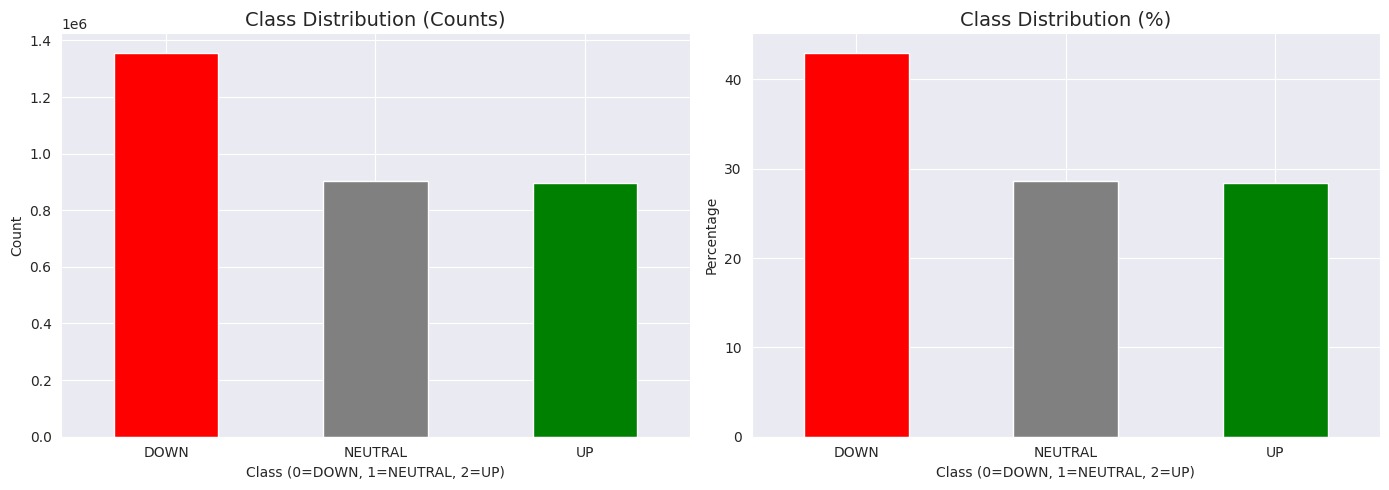

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
y.value_counts().plot(kind='bar', ax=axes[0], color=['red', 'gray', 'green'])
axes[0].set_title('Class Distribution (Counts)', fontsize=14)
axes[0].set_xlabel('Class (0=DOWN, 1=NEUTRAL, 2=UP)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['DOWN', 'NEUTRAL', 'UP'], rotation=0)

# Percentage plot
(y.value_counts(normalize=True) * 100).plot(kind='bar', ax=axes[1], color=['red', 'gray', 'green'])
axes[1].set_title('Class Distribution (%)', fontsize=14)
axes[1].set_xlabel('Class (0=DOWN, 1=NEUTRAL, 2=UP)')
axes[1].set_ylabel('Percentage')
axes[1].set_xticklabels(['DOWN', 'NEUTRAL', 'UP'], rotation=0)

plt.tight_layout()
plt.show()

### Sample Features

In [8]:
print("Sample features (first 5 rows):")
X.head()

Sample features (first 5 rows):


,close,log_ret_1m,log_ret_5m,ema_5,ema_9,ema_21,ema_50,rsi_7,rsi_14,bb_upper,bb_middle,bb_lower,bb_width,macd,macd_signal,macd_histogram,volume_ratio,sentiment_1h,sentiment_24h,mentions_zscore,sentiment_velocity,hour_sin,hour_cos
timestamp,,,,,,,,,,,,,,,,,,,,,,,
2024-08-08 13:19:00,58105.82,-0.001046,0.002113,58099.903432,58060.599521,57998.260834,57928.555794,64.601655,60.868897,58160.564314,57965.1585,57769.752686,0.006742,53.971226,29.970562,24.000665,2.161860,0.0,0.0,0.0,0.0,-0.258819,-0.965926
2024-08-08 13:20:00,58041.50,-0.001108,-0.000172,58080.435621,58056.779617,58002.191667,57932.984978,51.493952,54.708558,58166.832036,57968.6130,57770.393964,0.006839,50.238421,34.024133,16.214287,1.822916,0.0,0.0,0.0,0.0,-0.258819,-0.965926
2024-08-08 13:21:00,58039.21,-0.000039,-0.001047,58066.693748,58053.265693,58005.556970,57937.150665,51.063593,54.497084,58167.419372,57979.6875,57791.955628,0.006476,46.558663,36.531039,10.027623,2.274860,0.0,0.0,0.0,0.0,-0.258819,-0.965926
2024-08-08 13:22:00,57868.66,-0.002943,-0.004524,58000.682498,58016.344555,57993.111791,57934.464757,29.582046,41.599907,58165.642166,57980.7780,57795.913834,0.006377,29.539950,35.132821,-5.592872,1.073603,0.0,0.0,0.0,0.0,-0.258819,-0.965926
2024-08-08 13:23:00,57830.60,-0.000658,-0.005794,57943.988332,57979.195644,57978.337992,57930.391629,26.661872,39.361229,58170.929159,57975.8830,57780.836841,0.006729,12.833438,30.672945,-17.839507,1.133995,0.0,0.0,0.0,0.0,-0.258819,-0.965926


## 4. Train/Validation Split (Time-Series)

We use time-series split to avoid look-ahead bias - train on earlier data, validate on later data.

In [9]:
def time_series_split(X: pd.DataFrame, y: pd.Series, train_ratio: float = 0.8):
    """Split data by time, no shuffling."""
    split_idx = int(len(X) * train_ratio)
    
    X_train = X.iloc[:split_idx]
    y_train = y.iloc[:split_idx]
    X_val = X.iloc[split_idx:]
    y_val = y.iloc[split_idx:]
    
    return X_train, X_val, y_train, y_val


X_train, X_val, y_train, y_val = time_series_split(X, y, TRAIN_RATIO)

print(f"Train set: {len(X_train):,} samples")
print(f"Val set:   {len(X_val):,} samples")
print(f"\nTrain class distribution:")
print(y_train.value_counts())
print(f"\nVal class distribution:")
print(y_val.value_counts())

Train set: 2,525,043 samples
Val set:   631,261 samples

Train class distribution:
label
1    1069711
2     730579
0     724753
Name: count, dtype: int64

Val class distribution:
label
1    287357
0    172257
2    171647
Name: count, dtype: int64


In [10]:
def objective(trial, X_train, y_train, X_val, y_val):
    """Optuna objective for hyperparameter tuning."""
    params = {
        "objective": "multi:softprob",
        "num_class": 3,
        "eval_metric": "mlogloss",
        "tree_method": TREE_METHOD,  # Use GPU if available
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": 42,
    }
    
    # Add GPU-specific parameters
    if USE_GPU:
        params["device"] = "cuda"
    
    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )
    
    y_pred = model.predict(X_val)
    f1 = f1_score(y_val, y_pred, average="weighted")
    
    return f1

In [ ]:
print(f"Running Optuna optimization with {N_TRIALS} trials...")
print("This may take several minutes...\n")

study = optuna.create_study(direction="maximize")
study.optimize(
    lambda trial: objective(trial, X_train, y_train, X_val, y_val),
    n_trials=N_TRIALS,
    show_progress_bar=True,
)

print(f"\n{'='*60}")
print(f"Best trial F1-score: {study.best_trial.value:.4f}")
print(f"{'='*60}")
print(f"\nBest hyperparameters:")
for key, value in study.best_trial.params.items():
    print(f"  {key:20s}: {value}")

[I 2026-02-07 16:09:42,164] A new study created in memory with name: no-name-dbf823ed-9fad-4396-a970-269ffe5a3f74


Running Optuna optimization with 50 trials...
This may take several minutes...



  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:158: UserWarning: [16:10:05] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


[I 2026-02-07 16:10:05,815] Trial 0 finished with value: 0.4647634731216889 and parameters: {'max_depth': 4, 'learning_rate': 0.27334016093567687, 'n_estimators': 131, 'min_child_weight': 4, 'subsample': 0.9484371667791638, 'colsample_bytree': 0.9577129175700803, 'reg_alpha': 0.00030189845446679654, 'reg_lambda': 1.359690224467454e-05}. Best is trial 0 with value: 0.4647634731216889.
[I 2026-02-07 16:11:04,804] Trial 1 finished with value: 0.46684417405067286 and parameters: {'max_depth': 9, 'learning_rate': 0.05777114015777565, 'n_estimators': 318, 'min_child_weight': 10, 'subsample': 0.8769116017001232, 'colsample_bytree': 0.8407046607790372, 'reg_alpha': 0.008039667010435117, 'reg_lambda': 1.4078398105912821e-08}. Best is trial 1 with value: 0.46684417405067286.
[I 2026-02-07 16:11:37,628] Trial 2 finished with value: 0.4617630511069358 and parameters: {'max_depth': 4, 'learning_rate': 0.04641525136677602, 'n_estimators': 278, 'min_child_weight': 1, 'subsample': 0.9177793903620566, 

### Visualize Optimization History

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Optimization history
trial_values = [trial.value for trial in study.trials]
axes[0].plot(trial_values, marker='o', alpha=0.6)
axes[0].axhline(y=study.best_trial.value, color='r', linestyle='--', label=f'Best: {study.best_trial.value:.4f}')
axes[0].set_title('Optimization History', fontsize=14)
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('F1-score (weighted)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Parameter importance
try:
    importance = optuna.importance.get_param_importances(study)
    params = list(importance.keys())
    values = list(importance.values())
    
    axes[1].barh(params, values)
    axes[1].set_title('Hyperparameter Importance', fontsize=14)
    axes[1].set_xlabel('Importance')
    axes[1].grid(True, alpha=0.3, axis='x')
except:
    axes[1].text(0.5, 0.5, 'Insufficient trials for importance analysis', 
                 ha='center', va='center', fontsize=12)
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [ ]:
best_params = {
    "objective": "multi:softprob",
    "num_class": 3,
    "eval_metric": "mlogloss",
    "tree_method": TREE_METHOD,  # Use GPU if available
    "random_state": 42,
    **study.best_trial.params,
}

# Add GPU-specific parameters
if USE_GPU:
    best_params["device"] = "cuda"

print("Training final model with best hyperparameters...")
print(f"Using: {TREE_METHOD} ({'GPU' if USE_GPU else 'CPU'})\n")

model = xgb.XGBClassifier(**best_params)
model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=True,
)

print("\nTraining complete!")

## 7. Model Evaluation

In [ ]:
# Predictions
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_val_proba = model.predict_proba(X_val)

# Calculate metrics
train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)
train_f1 = f1_score(y_train, y_train_pred, average="weighted")
val_f1 = f1_score(y_val, y_val_pred, average="weighted")

print("="*60)
print("MODEL EVALUATION RESULTS")
print("="*60)
print(f"\nTrain Accuracy:      {train_acc:.4f}")
print(f"Val Accuracy:        {val_acc:.4f}")
print(f"\nTrain F1 (weighted): {train_f1:.4f}")
print(f"Val F1 (weighted):   {val_f1:.4f}")
print(f"\nOverfitting check:   {(train_acc - val_acc):.4f} (< 0.05 is good)")
print("\n" + "="*60)
print("CLASSIFICATION REPORT (Validation Set)")
print("="*60)
print(classification_report(y_val, y_val_pred, target_names=["DOWN", "NEUTRAL", "UP"]))

### Confusion Matrix

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix (counts)
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['DOWN', 'NEUTRAL', 'UP'],
            yticklabels=['DOWN', 'NEUTRAL', 'UP'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Confusion matrix (normalized)
cm_norm = confusion_matrix(y_val, y_val_pred, normalize='true')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['DOWN', 'NEUTRAL', 'UP'],
            yticklabels=['DOWN', 'NEUTRAL', 'UP'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14)
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

### Feature Importance

In [ ]:
# Get feature importance
importance_df = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 Most Important Features:")
print(importance_df.head(20))

# Plot feature importance
plt.figure(figsize=(12, 8))
top_n = 20
top_features = importance_df.head(top_n)
plt.barh(range(top_n), top_features['importance'].values)
plt.yticks(range(top_n), top_features['feature'].values)
plt.xlabel('Importance', fontsize=12)
plt.title(f'Top {top_n} Feature Importance', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Prediction Confidence Distribution

In [ ]:
# Get max probability for each prediction (confidence)
max_proba = y_val_proba.max(axis=1)

plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(max_proba, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Max Probability (Confidence)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Prediction Confidence Distribution', fontsize=14)
plt.axvline(x=0.5, color='r', linestyle='--', label='Threshold: 0.5')
plt.legend()
plt.grid(True, alpha=0.3)

# Box plot by class
plt.subplot(1, 2, 2)
confidence_by_class = pd.DataFrame({
    'True Class': y_val.map({0: 'DOWN', 1: 'NEUTRAL', 2: 'UP'}),
    'Confidence': max_proba
})
sns.boxplot(data=confidence_by_class, x='True Class', y='Confidence')
plt.title('Prediction Confidence by True Class', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nConfidence Statistics:")
print(f"  Mean confidence: {max_proba.mean():.4f}")
print(f"  Median confidence: {np.median(max_proba):.4f}")
print(f"  Min confidence: {max_proba.min():.4f}")
print(f"  Max confidence: {max_proba.max():.4f}")

## 8. Save Model and Metrics

In [ ]:
def save_model(model: xgb.XGBClassifier, output_dir: Path, metrics: dict):
    """Save model in multiple formats."""
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Save XGBoost native format
    model_path = output_dir / "xgboost_model.json"
    model.save_model(model_path)
    print(f"✓ Saved XGBoost model to {model_path}")
    
    # Save joblib format
    joblib_path = output_dir / "xgboost_model.joblib"
    joblib.dump(model, joblib_path)
    print(f"✓ Saved joblib model to {joblib_path}")
    
    # Save metrics
    metrics_path = output_dir / "metrics.json"
    with open(metrics_path, "w") as f:
        json.dump(metrics, f, indent=2, default=str)
    print(f"✓ Saved metrics to {metrics_path}")
    
    # Save feature names
    features_path = output_dir / "features.json"
    with open(features_path, "w") as f:
        json.dump(FEATURE_COLUMNS, f, indent=2)
    print(f"✓ Saved feature names to {features_path}")


# Prepare metrics dictionary
metrics = {
    "train_accuracy": float(train_acc),
    "val_accuracy": float(val_acc),
    "train_f1_weighted": float(train_f1),
    "val_f1_weighted": float(val_f1),
    "train_size": len(X_train),
    "val_size": len(X_val),
    "symbols": SYMBOLS,
    "threshold": THRESHOLD,
    "best_params": best_params,
    "n_features": len(FEATURE_COLUMNS),
}

# Save everything
print("\nSaving model and artifacts...")
save_model(model, OUTPUT_DIR, metrics)
print("\n✓ All artifacts saved successfully!")

## 9. Model Summary

In [ ]:
print("="*60)
print("FINAL MODEL SUMMARY")
print("="*60)
print(f"\nTraining Data:")
print(f"  Symbols: {', '.join(SYMBOLS)}")
print(f"  Total samples: {len(X):,}")
print(f"  Features: {len(FEATURE_COLUMNS)}")
print(f"  Return threshold: {THRESHOLD*100:.3f}%")
print(f"\nData Split:")
print(f"  Train: {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Val:   {len(X_val):,} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"\nPerformance:")
print(f"  Train Accuracy: {train_acc:.4f}")
print(f"  Val Accuracy:   {val_acc:.4f}")
print(f"  Train F1:       {train_f1:.4f}")
print(f"  Val F1:         {val_f1:.4f}")
print(f"\nModel saved to: {OUTPUT_DIR}")
print("="*60)

## 10. Quick Model Test

Test the model with a sample prediction:

## GPU Performance Notes

### Expected Speedup with GPU

When using Google Colab GPU (T4/V100/A100):

| Task | CPU Time | GPU Time | Speedup |
|------|----------|----------|---------|
| **Optuna (50 trials)** | ~15-30 min | ~3-5 min | **5-10x faster** |
| **Final Training** | ~2-5 min | ~20-40 sec | **3-7x faster** |
| **Per Tree** | Slower | Faster | GPU shines with many trees |

### GPU Training Tips

1. **Larger datasets benefit more** - GPU overhead is worth it for 100K+ samples
2. **More trees = better GPU utilization** - Consider increasing `n_estimators` range to 100-1000
3. **Batch size matters** - XGBoost automatically optimizes for GPU
4. **Memory limitations** - Watch out for CUDA out-of-memory errors with very large datasets

### Troubleshooting

If you get CUDA errors:
- Restart runtime and clear outputs
- Reduce dataset size or number of features
- Lower `n_estimators` temporarily
- Check GPU memory: `!nvidia-smi`

In [ ]:
# Get a random sample from validation set
idx = np.random.randint(0, len(X_val))
sample = X_val.iloc[idx:idx+1]
true_label = y_val.iloc[idx]

# Make prediction
pred_label = model.predict(sample)[0]
pred_proba = model.predict_proba(sample)[0]

label_names = {0: 'DOWN', 1: 'NEUTRAL', 2: 'UP'}

print("Sample Prediction:")
print(f"\nTrue label:      {label_names[true_label]}")
print(f"Predicted label: {label_names[pred_label]}")
print(f"\nPrediction probabilities:")
print(f"  DOWN:    {pred_proba[0]:.4f} ({pred_proba[0]*100:.2f}%)")
print(f"  NEUTRAL: {pred_proba[1]:.4f} ({pred_proba[1]*100:.2f}%)")
print(f"  UP:      {pred_proba[2]:.4f} ({pred_proba[2]*100:.2f}%)")
print(f"\nCorrect: {'✓ Yes' if pred_label == true_label else '✗ No'}")

## Next Steps

1. **Export to ONNX** (for Go inference): Run `export_model.py --format onnx`
2. **Backtest**: Use the saved model in the Go backtesting engine
3. **Paper Trading**: Test with live data before real deployment
4. **Retrain**: Periodically retrain with fresh data to adapt to market changes

## Notes

- Model is saved in multiple formats for flexibility
- Use time-series cross-validation for more robust evaluation
- Consider feature selection to reduce model complexity
- Monitor model performance degradation in production
- Retrain when validation metrics drop significantly